In [1]:
import os
import sys

# Add project root to path
project_root = os.path.dirname(os.getcwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import matplotlib.pyplot as plt
from src.loader import get_latest_cdt_analysis, get_latest_gonogo_analysis, get_latest_sst_analysis


file_name = '../data/hand_analysis/2026-01-08_10-44-37/analysis.csv'

df_tmt_complete = pd.read_csv(file_name, on_bad_lines='warn')


# 1. Filter Valid Trials
df_valid = df_tmt_complete[df_tmt_complete['is_valid'] == True].copy()

df_valid = df_valid[df_valid['age'] > 0]

# 2. Map Trial Types
def get_part(trial_type):
    tt = str(trial_type).upper()
    if 'PART_A' in tt: return 'A'
    if 'PART_B' in tt: return 'B'
    return None

df_valid['Part'] = df_valid['trial_type'].apply(get_part)
df_valid = df_valid.dropna(subset=['Part'])  # Remove non-TMT trials if any

# 3. Pivot Data (Subject x Part)
# We extract Time (non_cut_rt) and Errors (non_cut_wrong_targets_touches)
pivot_rt = df_valid.pivot_table(index='subject_id', columns='Part', values='non_cut_rt')
pivot_err = df_valid.pivot_table(index='subject_id', columns='Part', values='non_cut_wrong_targets_touches')

# Rename columns
pivot_rt.columns = [f'Time_{c}' for c in pivot_rt.columns]
pivot_err.columns = [f'Errors_{c}' for c in pivot_err.columns]

# Merge Time and Errors
df_tmt = pivot_rt.join(pivot_err)

# 4. Apply Strict Filter (Must have A and B)
initial_n = len(df_tmt)
df_tmt = df_tmt.dropna()
final_n = len(df_tmt)

print(f"Subjects with valid data (at least one part): {initial_n}")
print(f"Subjects with COMPLETE data (Strict Criteria): {final_n}")
print(f"Excluded: {initial_n - final_n}")

# Unit Conversion (ms to seconds check)
if df_tmt['Time_A'].mean() > 1000:
    print("\nCreating columns in Seconds (converted from ms)...")
    df_tmt['Time_A_sec'] = df_tmt['Time_A'] / 1000
    df_tmt['Time_B_sec'] = df_tmt['Time_B'] / 1000
else:
    df_tmt['Time_A_sec'] = df_tmt['Time_A']
    df_tmt['Time_B_sec'] = df_tmt['Time_B']

df_tmt.head()

Subjects with valid data (at least one part): 343
Subjects with COMPLETE data (Strict Criteria): 329
Excluded: 14

Creating columns in Seconds (converted from ms)...


,Time_A,Time_B,Errors_A,Errors_B,Time_A_sec,Time_B_sec
subject_id,,,,,,
000b56b2-809c-4acf-9139-1265ecfa284e,24431.666667,24598.500000,0.333333,0.000000,24.431667,24.598500
026d71e0-ded4-488b-ab2a-9c9b7bed0eba,20627.600000,24491.000000,0.100000,1.111111,20.627600,24.491000
03ac286b-6c27-4427-bbed-0f0e607a3ac3,20406.888889,22795.444444,0.222222,0.333333,20.406889,22.795444
03ed4d2a-44f7-47f9-a966-712dfb380a9a,20451.800000,24312.600000,0.700000,1.400000,20.451800,24.312600
046572d0-518e-4207-b8af-92b01233f4de,24570.000000,24504.000000,0.333333,0.000000,24.570000,24.504000


In [2]:
df_tmt_complete['subject_id'].nunique()

356

In [3]:
df_sst, _ = get_latest_sst_analysis()
df_cdt, _ = get_latest_cdt_analysis()
df_gonogo, _ = get_latest_gonogo_analysis()

run_dirs: [PosixPath('/home/gus/Documents/REPOS/datapruebas_analysis/data/cdt_analysis/2026-01-08_10-54-21'), PosixPath('/home/gus/Documents/REPOS/datapruebas_analysis/data/cdt_analysis/2025-12-19_17-39-11'), PosixPath('/home/gus/Documents/REPOS/datapruebas_analysis/data/cdt_analysis/2025-12-19_17-10-47')]


In [4]:
print(df_sst['subject_id'].nunique())
print(df_cdt['subject_id'].nunique())
print(df_gonogo['subject_id'].nunique())
print(df_tmt.reset_index()['subject_id'].nunique())

246
248
310
329


In [5]:
# Start by merging the first two dataframes
merged_df = pd.merge(df_tmt, df_sst, on='subject_id', how='outer') 

# Merge the result with the third dataframe
merged_df = pd.merge(merged_df, df_cdt, on='subject_id', how='outer',)

# Merge the result with the fourth dataframe
final_df = pd.merge(merged_df, df_gonogo, on='subject_id', how='outer')

print(final_df['subject_id'].nunique())

552


In [6]:
final_df

,subject_id,Time_A,Time_B,Errors_A,Errors_B,Time_A_sec,Time_B_sec,Nstop,presp,ssd,...,user_agent,device,browser,platform,n_go_trials,n_nogo_trials,c,HR_FA_sin_estandarizar,sensibilidad,origin
0,000b56b2-809c-4acf-9139-1265ecfa284e,24431.666667,24598.500000,0.333333,0.000000,24.431667,24.598500,64.0,0.53125,377.0,...,Mozilla/5.0 (Macintosh; Intel Mac OS X 10.15; ...,Macintosh,Firefox 97.0,OS X 10.15,105.0,45.0,-0.81,-0.67,-2.57,neuropruebas
1,026d71e0-ded4-488b-ab2a-9c9b7bed0eba,20627.600000,24491.000000,0.100000,1.111111,20.627600,24.491000,64.0,0.43750,567.0,...,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,WebKit,Chrome 99.0.4844.51,Windows 10.0,105.0,45.0,0.55,-0.49,-1.35,neuropruebas
2,03ac286b-6c27-4427-bbed-0f0e607a3ac3,20406.888889,22795.444444,0.222222,0.333333,20.406889,22.795444,64.0,0.46875,231.0,...,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,WebKit,Chrome 100.0.4896.75,Windows 10.0,105.0,45.0,-0.31,-0.57,1.96,neuropruebas
3,03ed4d2a-44f7-47f9-a966-712dfb380a9a,20451.800000,24312.600000,0.700000,1.400000,20.451800,24.312600,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,046572d0-518e-4207-b8af-92b01233f4de,24570.000000,24504.000000,0.333333,0.000000,24.570000,24.504000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
547,bca9751d-800e-4f79-bbef-89f4a93d9f3c,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,WebKit,Opera 89.0.4447.104,Windows 10.0,105.0,45.0,-0.29,-0.56,2.20,neuropruebas
548,josefinamercedescaso@gmail.com-new-go-nogo_110,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,WebKit,Chrome 93.0.4577.82,Windows 10.0,105.0,45.0,0.95,-0.43,-0.55,neuropruebas
549,d9eeb135-7996-491a-81f5-09b4826c7808,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Mozilla/5.0 (Windows NT 6.1; Win64; x64) Apple...,WebKit,Chrome 102.0.0.0,Windows 6.1,105.0,45.0,0.08,-0.55,-1.73,neuropruebas
550,gonzalocagnola@gmail.com-new-go-nogo_116,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,WebKit,Chrome 94.0.4606.61,Windows 10.0,105.0,45.0,-0.85,-0.64,1.45,neuropruebas


In [7]:
# Start by merging the first two dataframes
merged_df = pd.merge(df_tmt, df_sst, on='subject_id', how='inner')

# Merge the result with the third dataframe
merged_df = pd.merge(merged_df, df_cdt, on='subject_id', how='inner',)

# Merge the result with the fourth dataframe
final_df = pd.merge(merged_df, df_gonogo, on='subject_id', how='inner')

print(final_df['subject_id'].nunique())

128


In [8]:
metadata = df_tmt_complete[['subject_id','age', 'gender', 'education_level', 'nationality']].groupby('subject_id').first().reset_index()
metadata = pd.merge(metadata, final_df, on='subject_id', how='inner')
metadata

,subject_id,age,gender,education_level,nationality,Time_A,Time_B,Errors_A,Errors_B,Time_A_sec,...,user_agent,device,browser,platform,n_go_trials,n_nogo_trials,c,HR_FA_sin_estandarizar,sensibilidad,origin
0,000b56b2-809c-4acf-9139-1265ecfa284e,56,M,R,Argentina,24431.666667,24598.500000,0.333333,0.000000,24.431667,...,Mozilla/5.0 (Macintosh; Intel Mac OS X 10.15; ...,Macintosh,Firefox 97.0,OS X 10.15,105,45,-0.81,-0.67,-2.57,neuropruebas
1,026d71e0-ded4-488b-ab2a-9c9b7bed0eba,24,F,U,Argentina,20627.600000,24491.000000,0.100000,1.111111,20.627600,...,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,WebKit,Chrome 99.0.4844.51,Windows 10.0,105,45,0.55,-0.49,-1.35,neuropruebas
2,03ac286b-6c27-4427-bbed-0f0e607a3ac3,26,M,U,Uruguay,20406.888889,22795.444444,0.222222,0.333333,20.406889,...,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,WebKit,Chrome 100.0.4896.75,Windows 10.0,105,45,-0.31,-0.57,1.96,neuropruebas
3,06c54d33-ee13-40de-bc70-15f640c8c325,50,F,U,Argentina,18014.500000,24946.500000,0.000000,0.500000,18.014500,...,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,WebKit,Chrome 99.0.4844.82,Windows 10.0,105,45,-1.47,-0.74,-2.40,neuropruebas
4,075b58cb-69b4-42c1-b1cd-95325bc36df5,24,M,U,Argentina,20459.100000,22103.700000,0.200000,0.000000,20.459100,...,NaN,NaN,NaN,NaN,105,45,-0.57,-0.61,0.89,datapruebas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,f5e7c9df-3be8-44c3-9811-9861ec946787,25,F,T,España,19802.200000,23862.800000,0.100000,0.800000,19.802200,...,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,WebKit,Chrome 101.0.4951.54,Windows 10.0,105,45,0.18,-0.51,2.58,neuropruebas
124,f612e87c-97f0-4ad9-a4ce-00ab1fcd0177,27,F,S,argentina,22634.750000,23157.428571,1.250000,1.142857,22.634750,...,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,WebKit,Chrome 99.0.4844.84,Windows 10.0,105,45,0.15,-0.53,0.46,neuropruebas
125,f7d6c913-50c1-450c-9294-5eccd2f40212,33,F,T,Argentina,21605.222222,23802.875000,0.222222,0.000000,21.605222,...,Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...,Macintosh,Chrome 101.0.4951.64,OS X 10_15_7,105,45,0.12,-0.53,0.22,neuropruebas
126,fa99b0ec-c1d7-45cd-9b81-ac348a6339a1,33,F,U,Argentina,21827.857143,24787.400000,1.714286,0.000000,21.827857,...,NaN,NaN,NaN,NaN,105,45,-0.60,-0.61,0.65,datapruebas


In [9]:
metadata['gender'].value_counts()

gender
F    67
M    59
G     1
N     1
Name: count, dtype: int64

<Axes: xlabel='education_level'>

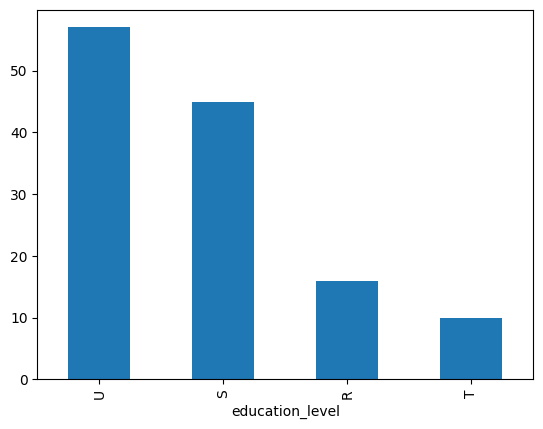

In [10]:
metadata['education_level'].value_counts().plot.bar()

In [11]:
# Diccionario de mapeo para education_level
education_level_map = {
    'P': 'Primaria completa',
    'S': 'Secundaria completa',
    'T': 'Terciaria completa',
    'U': 'Universitaria completa',
    'R': 'Posgrado completo'
}

# Aplicar el mapeo a la columna education_level
metadata['education_level_desc'] = metadata['education_level'].map(education_level_map)
metadata

,subject_id,age,gender,education_level,nationality,Time_A,Time_B,Errors_A,Errors_B,Time_A_sec,...,device,browser,platform,n_go_trials,n_nogo_trials,c,HR_FA_sin_estandarizar,sensibilidad,origin,education_level_desc
0,000b56b2-809c-4acf-9139-1265ecfa284e,56,M,R,Argentina,24431.666667,24598.500000,0.333333,0.000000,24.431667,...,Macintosh,Firefox 97.0,OS X 10.15,105,45,-0.81,-0.67,-2.57,neuropruebas,Posgrado completo
1,026d71e0-ded4-488b-ab2a-9c9b7bed0eba,24,F,U,Argentina,20627.600000,24491.000000,0.100000,1.111111,20.627600,...,WebKit,Chrome 99.0.4844.51,Windows 10.0,105,45,0.55,-0.49,-1.35,neuropruebas,Universitaria completa
2,03ac286b-6c27-4427-bbed-0f0e607a3ac3,26,M,U,Uruguay,20406.888889,22795.444444,0.222222,0.333333,20.406889,...,WebKit,Chrome 100.0.4896.75,Windows 10.0,105,45,-0.31,-0.57,1.96,neuropruebas,Universitaria completa
3,06c54d33-ee13-40de-bc70-15f640c8c325,50,F,U,Argentina,18014.500000,24946.500000,0.000000,0.500000,18.014500,...,WebKit,Chrome 99.0.4844.82,Windows 10.0,105,45,-1.47,-0.74,-2.40,neuropruebas,Universitaria completa
4,075b58cb-69b4-42c1-b1cd-95325bc36df5,24,M,U,Argentina,20459.100000,22103.700000,0.200000,0.000000,20.459100,...,NaN,NaN,NaN,105,45,-0.57,-0.61,0.89,datapruebas,Universitaria completa
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,f5e7c9df-3be8-44c3-9811-9861ec946787,25,F,T,España,19802.200000,23862.800000,0.100000,0.800000,19.802200,...,WebKit,Chrome 101.0.4951.54,Windows 10.0,105,45,0.18,-0.51,2.58,neuropruebas,Terciaria completa
124,f612e87c-97f0-4ad9-a4ce-00ab1fcd0177,27,F,S,argentina,22634.750000,23157.428571,1.250000,1.142857,22.634750,...,WebKit,Chrome 99.0.4844.84,Windows 10.0,105,45,0.15,-0.53,0.46,neuropruebas,Secundaria completa
125,f7d6c913-50c1-450c-9294-5eccd2f40212,33,F,T,Argentina,21605.222222,23802.875000,0.222222,0.000000,21.605222,...,Macintosh,Chrome 101.0.4951.64,OS X 10_15_7,105,45,0.12,-0.53,0.22,neuropruebas,Terciaria completa
126,fa99b0ec-c1d7-45cd-9b81-ac348a6339a1,33,F,U,Argentina,21827.857143,24787.400000,1.714286,0.000000,21.827857,...,NaN,NaN,NaN,105,45,-0.60,-0.61,0.65,datapruebas,Universitaria completa


In [12]:
metadata['education_level'].value_counts()


education_level
U    57
S    45
R    16
T    10
Name: count, dtype: int64

## Age

In [13]:
# Sanitizing
# metadata['age'].iloc[334]
# BAD_ROW_NON_AGE = metadata.iloc[334]['subject_id']
# metadata = metadata[metadata['subject_id'] != BAD_ROW_NON_AGE]
# metadata['age'] = metadata['age'].astype(int)

In [14]:
metadata = metadata[metadata['age'] > 0]

In [15]:
metadata[metadata['age']< 0]

,subject_id,age,gender,education_level,nationality,Time_A,Time_B,Errors_A,Errors_B,Time_A_sec,...,device,browser,platform,n_go_trials,n_nogo_trials,c,HR_FA_sin_estandarizar,sensibilidad,origin,education_level_desc


Text(0.5, 0, 'Age (years)')

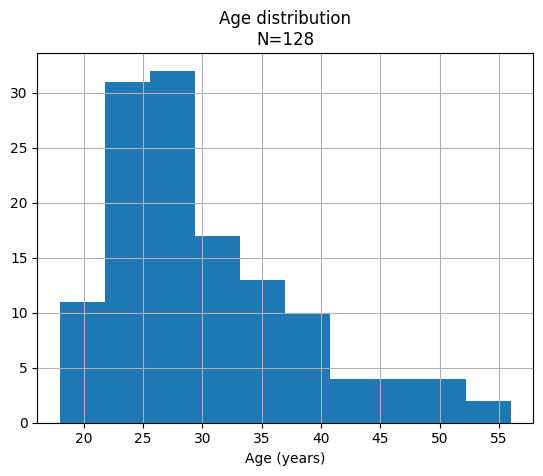

In [25]:
metadata = metadata[metadata['age'] > 0]
metadata = metadata[metadata['age'] < 100]

metadata['age'].hist()
plt.title(f"Age distribution\nN={len(metadata)}")
plt.xlabel("Age (years)")

<Axes: xlabel='education_level'>

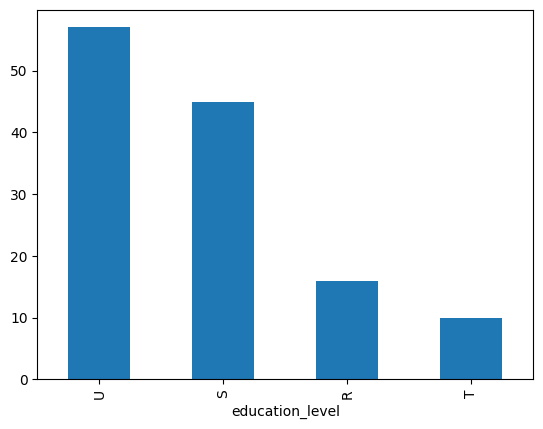

In [17]:
#plot bar
metadata['education_level'].value_counts().plot.bar()

In [18]:
education_level_map = {
    'P': 'Primary school complete',
    'S': 'Secondary school complete',
    'T': 'Tertiary education complete',
    'U': 'University degree complete',
    'R': 'Postgraduate degree complete'
}

# Aplicar el mapeo a la columna education_level
metadata['education_level_desc'] = metadata['education_level'].map(education_level_map)
metadata

,subject_id,age,gender,education_level,nationality,Time_A,Time_B,Errors_A,Errors_B,Time_A_sec,...,device,browser,platform,n_go_trials,n_nogo_trials,c,HR_FA_sin_estandarizar,sensibilidad,origin,education_level_desc
0,000b56b2-809c-4acf-9139-1265ecfa284e,56,M,R,Argentina,24431.666667,24598.500000,0.333333,0.000000,24.431667,...,Macintosh,Firefox 97.0,OS X 10.15,105,45,-0.81,-0.67,-2.57,neuropruebas,Postgraduate degree complete
1,026d71e0-ded4-488b-ab2a-9c9b7bed0eba,24,F,U,Argentina,20627.600000,24491.000000,0.100000,1.111111,20.627600,...,WebKit,Chrome 99.0.4844.51,Windows 10.0,105,45,0.55,-0.49,-1.35,neuropruebas,University degree complete
2,03ac286b-6c27-4427-bbed-0f0e607a3ac3,26,M,U,Uruguay,20406.888889,22795.444444,0.222222,0.333333,20.406889,...,WebKit,Chrome 100.0.4896.75,Windows 10.0,105,45,-0.31,-0.57,1.96,neuropruebas,University degree complete
3,06c54d33-ee13-40de-bc70-15f640c8c325,50,F,U,Argentina,18014.500000,24946.500000,0.000000,0.500000,18.014500,...,WebKit,Chrome 99.0.4844.82,Windows 10.0,105,45,-1.47,-0.74,-2.40,neuropruebas,University degree complete
4,075b58cb-69b4-42c1-b1cd-95325bc36df5,24,M,U,Argentina,20459.100000,22103.700000,0.200000,0.000000,20.459100,...,NaN,NaN,NaN,105,45,-0.57,-0.61,0.89,datapruebas,University degree complete
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,f5e7c9df-3be8-44c3-9811-9861ec946787,25,F,T,España,19802.200000,23862.800000,0.100000,0.800000,19.802200,...,WebKit,Chrome 101.0.4951.54,Windows 10.0,105,45,0.18,-0.51,2.58,neuropruebas,Tertiary education complete
124,f612e87c-97f0-4ad9-a4ce-00ab1fcd0177,27,F,S,argentina,22634.750000,23157.428571,1.250000,1.142857,22.634750,...,WebKit,Chrome 99.0.4844.84,Windows 10.0,105,45,0.15,-0.53,0.46,neuropruebas,Secondary school complete
125,f7d6c913-50c1-450c-9294-5eccd2f40212,33,F,T,Argentina,21605.222222,23802.875000,0.222222,0.000000,21.605222,...,Macintosh,Chrome 101.0.4951.64,OS X 10_15_7,105,45,0.12,-0.53,0.22,neuropruebas,Tertiary education complete
126,fa99b0ec-c1d7-45cd-9b81-ac348a6339a1,33,F,U,Argentina,21827.857143,24787.400000,1.714286,0.000000,21.827857,...,NaN,NaN,NaN,105,45,-0.60,-0.61,0.65,datapruebas,University degree complete


In [19]:
metadata['education_level_desc'].value_counts()

education_level_desc
University degree complete      57
Secondary school complete       45
Postgraduate degree complete    16
Tertiary education complete     10
Name: count, dtype: int64

Text(0.5, 0, ' ')

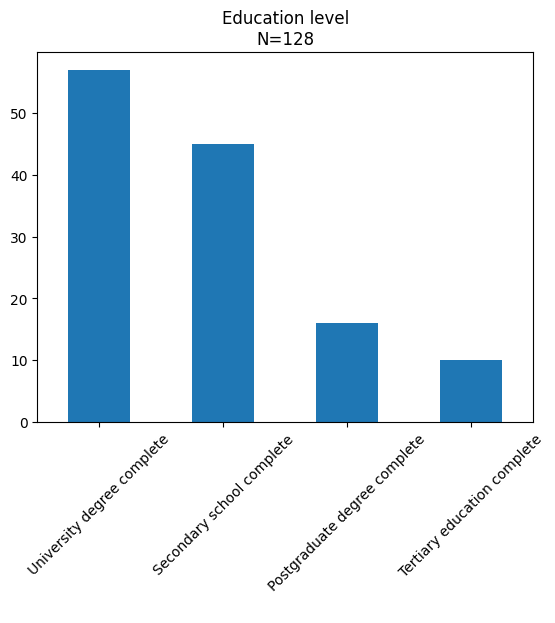

In [28]:
metadata['education_level_desc'].value_counts().plot.bar(rot=45)
plt.title(f"Education level\nN={len(metadata)}")
plt.xlabel(' ')

In [49]:
metadata['education_level_desc'].value_counts()

education_level_desc
University degree complete      57
Secondary school complete       45
Postgraduate degree complete    16
Tertiary education complete     10
Name: count, dtype: int64

In [21]:
metadata['nationality'].value_counts()

nationality
Argentina                  87
Argentino                  10
argentina                   9
Uruguaya                    3
Venezuela                   2
argentino                   2
Colombia                    2
uruguaya                    2
martinezl.flo@gmail.com     1
Colombiano                  1
venezolana                  1
ecuatoriana                 1
Peruano                     1
peruana                     1
Venezolana                  1
Uruguay                     1
Mexicana                    1
franco argentino            1
España                      1
Name: count, dtype: int64

In [31]:
!pip install thefuzz

In [41]:
import pandas as pd
import difflib

# 1. Tu lista estándar de países (Asegúrate de que estén bien escritos aquí)
clean_countries = [
    "Argentina", "Uruguay", "Colombia", "Venezuela", 
    "Mexico", "Peru", "Chile", "Ecuador", "Spain", "Bolivia", "Dominican Republic"
]

# 2. Función de reemplazo usando difflib
def match_country(raw_country):
    if pd.isna(raw_country):
        return raw_country
    
    # Busca la coincidencia más cercana
    # cutoff=0.6 significa 60% de similitud mínima requerida
    matches = difflib.get_close_matches(str(raw_country), clean_countries, n=1, cutoff=0.6)
    
    if matches:
        return matches[0] # Retorna el nombre limpio
    return 'other' # Si no encuentra parecido, deja el original (o pon "Other")

# 3. Aplicar al DataFrame (Asumiendo que tu DF se llama 'df_merged' o similar)
# Reemplaza 'nationality' con el nombre real de tu columna
metadata['nationality_clean'] = metadata['nationality'].apply(match_country)

Función lista para usarse con difflib.


Text(0.5, 0, ' ')

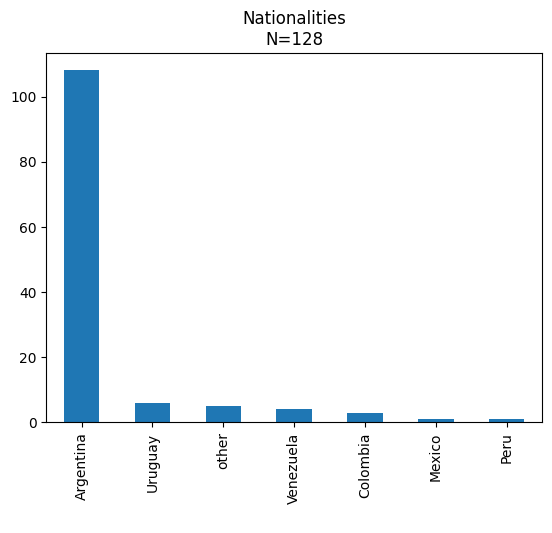

In [43]:
metadata['nationality_clean'].value_counts().plot.bar()
plt.title(f'Nationalities\nN={len(metadata)}')
plt.xlabel(' ')

In [48]:
metadata['nationality_clean'].value_counts()

nationality_clean
Argentina    108
Uruguay        6
other          5
Venezuela      4
Colombia       3
Mexico         1
Peru           1
Name: count, dtype: int64

In [45]:
GENDER_CHOICES = {
    'M': 'Male',
    'F': 'Female',
    'N': 'Non-binary',
    'G': 'Gender fluid',
    'O': 'None of these options identify me',
    'D': 'Prefer not to say',
}

# Aplicar el mapeo a la columna education_level
metadata['gender_choice'] = metadata['gender'].map(GENDER_CHOICES)
metadata


,subject_id,age,gender,education_level,nationality,Time_A,Time_B,Errors_A,Errors_B,Time_A_sec,...,platform,n_go_trials,n_nogo_trials,c,HR_FA_sin_estandarizar,sensibilidad,origin,education_level_desc,gender_choice,nationality_clean
0,000b56b2-809c-4acf-9139-1265ecfa284e,56,M,R,Argentina,24431.666667,24598.500000,0.333333,0.000000,24.431667,...,OS X 10.15,105,45,-0.81,-0.67,-2.57,neuropruebas,Postgraduate degree complete,Male,Argentina
1,026d71e0-ded4-488b-ab2a-9c9b7bed0eba,24,F,U,Argentina,20627.600000,24491.000000,0.100000,1.111111,20.627600,...,Windows 10.0,105,45,0.55,-0.49,-1.35,neuropruebas,University degree complete,Female,Argentina
2,03ac286b-6c27-4427-bbed-0f0e607a3ac3,26,M,U,Uruguay,20406.888889,22795.444444,0.222222,0.333333,20.406889,...,Windows 10.0,105,45,-0.31,-0.57,1.96,neuropruebas,University degree complete,Male,Uruguay
3,06c54d33-ee13-40de-bc70-15f640c8c325,50,F,U,Argentina,18014.500000,24946.500000,0.000000,0.500000,18.014500,...,Windows 10.0,105,45,-1.47,-0.74,-2.40,neuropruebas,University degree complete,Female,Argentina
4,075b58cb-69b4-42c1-b1cd-95325bc36df5,24,M,U,Argentina,20459.100000,22103.700000,0.200000,0.000000,20.459100,...,NaN,105,45,-0.57,-0.61,0.89,datapruebas,University degree complete,Male,Argentina
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
123,f5e7c9df-3be8-44c3-9811-9861ec946787,25,F,T,España,19802.200000,23862.800000,0.100000,0.800000,19.802200,...,Windows 10.0,105,45,0.18,-0.51,2.58,neuropruebas,Tertiary education complete,Female,other
124,f612e87c-97f0-4ad9-a4ce-00ab1fcd0177,27,F,S,argentina,22634.750000,23157.428571,1.250000,1.142857,22.634750,...,Windows 10.0,105,45,0.15,-0.53,0.46,neuropruebas,Secondary school complete,Female,Argentina
125,f7d6c913-50c1-450c-9294-5eccd2f40212,33,F,T,Argentina,21605.222222,23802.875000,0.222222,0.000000,21.605222,...,OS X 10_15_7,105,45,0.12,-0.53,0.22,neuropruebas,Tertiary education complete,Female,Argentina
126,fa99b0ec-c1d7-45cd-9b81-ac348a6339a1,33,F,U,Argentina,21827.857143,24787.400000,1.714286,0.000000,21.827857,...,NaN,105,45,-0.60,-0.61,0.65,datapruebas,University degree complete,Female,Argentina


Text(0.5, 0, ' ')

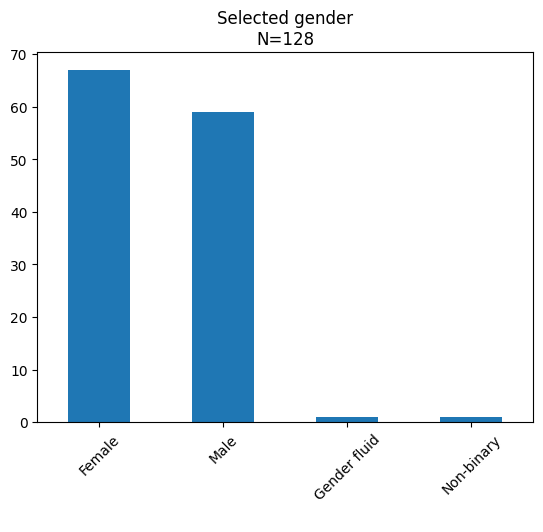

In [46]:
metadata['gender_choice'].value_counts().plot.bar(rot=45)
plt.title(f"Selected gender\nN={len(metadata)}")
plt.xlabel(" ")

In [47]:
metadata['gender_choice'].value_counts()

gender_choice
Female          67
Male            59
Gender fluid     1
Non-binary       1
Name: count, dtype: int64

In [84]:
metadata.describe()

,age,Time_A,Time_B,Errors_A,Errors_B,Time_A_sec,Time_B_sec
count,328.000000,328.000000,328.000000,328.000000,328.000000,328.000000,328.000000
mean,31.685976,21859.437009,23806.478028,0.482223,0.459307,21.859437,23.806478
std,9.797125,2174.315004,1188.724912,0.771945,0.732526,2.174315,1.188725
min,18.000000,14714.000000,18000.700000,0.000000,0.000000,14.714000,18.000700
25%,25.000000,20440.572222,23490.027778,0.100000,0.000000,20.440572,23.490028
50%,29.000000,22373.300000,24214.562500,0.250000,0.200000,22.373300,24.214562
75%,36.000000,23577.375000,24591.416667,0.555556,0.625000,23.577375,24.591417
max,77.000000,24898.833333,24981.000000,7.500000,8.000000,24.898833,24.981000


In [85]:
metadata['gender_choice'].value_counts()

gender_choice
Female                               164
Male                                 156
Gender fluid                           3
Non-binary                             3
None of these options identify me      1
Prefer not to say                      1
Name: count, dtype: int64